In [1]:
import ultraplot as uplt
# import matplotlib.pyplot as plt
import numpy as np

In [42]:
import warnings

import healpy as hp
import numpy as np
import numpy.typing as npt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time

from rubin_scheduler.utils import DEFAULT_NSIDE, _hpid2_ra_dec

from rubin_scheduler.scheduler.utils.sky_area import CurrentAreaMap
from rubin_scheduler.scheduler.utils.footprints import (
    Footprint,
    StepSlopes,
    Footprints,
    slice_quad_galactic_cut,
)

# survey start from commit 5e34aa5102d3d44fc03c2a74934338fc2ba2d1b9
# on https://github.com/lsst-sims/sims_featureScheduler_runs5.3
SURVEY_START_MJD = Time("2026-06-15T12:00:00").mjd

# default function from commit e6d604718bcf3253434c8ddfee0250d9d09b5c8e
# on rubin_scheduler
def make_rolling_footprints(
    fp_hp=None,
    mjd_start=60218.0,
    sun_ra_start=3.27717639,
    nslice=2,
    scale=0.8,
    nside=DEFAULT_NSIDE,
    wfd_indx=None,
    order_roll=0,
    n_cycles=None,
    n_constant_start=2,
    n_constant_end=6,
    verbose=False,
    uniform=True,
    matts_custom_strategy=None,
):
    """
    Generate rolling footprints

    Parameters
    ----------
    fp_hp : dict-like
        A dict with band name keys and HEALpix map values.
        Default None will load CurrentAreaMap. Assumes
        WFD is where r-band is 1.
    mjd_start : `float`
        The starting date of the survey.
    sun_ra_start : `float`
        The RA of the sun at the start of the survey
    nslice : `int`
        How much to slice the sky up. Can be 2, 3, 4, or 6.
    scale : `float`
        The strength of the rolling, value of 1 is full power rolling.
        Zero is no rolling.
    wfd_indx : array of ints
        The indices of the HEALpix map that are to be included in the rolling.
    order_roll : `int`
        Change the order of when bands roll. Default 0.
    n_cycles : `int`
        Number of complete rolling cycles to attempt. If None, defaults to 3
        full cycles for nslice=2, 2 cycles for nslice=3 or 4, and 1 cycle for
        nslice=6.
    n_constant_start : `int`
        The number of constant non-rolling seasons to start with. Anything
        less than 2 will start rolling too early near Y1. Defaults to 2.
    n_constant_end : `int`
        The number of constant seasons to end the survey with. Defaults to 6.

    Returns
    -------
    Footprints object
    """

    if fp_hp is None:
        sky = CurrentAreaMap(nside=nside)
        footprints, labels = sky.return_maps()
        fp_hp = {}
        for key in footprints.dtype.names:
            fp_hp[key] = footprints[key]

    nc_default = {2: 3, 3: 2, 4: 2, 6: 1}
    if n_cycles is None:
        n_cycles = nc_default[nslice]

    hp_footprints = fp_hp

    D = 1.0 - scale
    U = nslice - D * (nslice - 1)

    start = [1.0] * n_constant_start
    # After n_cycles, just go to no-rolling for 6 years.
    end = [1.0] * n_constant_end

    rolling = [U] + [D] * (nslice - 1)
    rolling = np.roll(rolling, order_roll).tolist()

    all_slopes = []
    if uniform:
        extra_constant = [1]
    else:
        extra_constant = []

    for i in range(nslice):
        _roll = np.roll(rolling, i).tolist() + extra_constant
        all_slopes.append(start + _roll * n_cycles + end)
    for i in range(nslice):
        _roll = np.roll(rolling, i).tolist() + extra_constant
        _roll = [_roll[-1]] + _roll[1:-1] + [_roll[0]]
        all_slopes.append(start + _roll * n_cycles + end)
    dvals = {
        1: "1",
        D: "D",
        U: "U",
    }
    inv_dvals = {v: k for k, v in dvals.items()}

    if matts_custom_strategy is not None:
        print("using Matt's custom survey strategy:", matts_custom_strategy)

        if matts_custom_strategy == "u2_uroll1_broll2":
            # uniform rolling looks like this:
            # slice a w/ ra - sun_ra in [270, 90]: 1 1 D U 1 D U 1 D U 1 1 1 1 1 1 1
            # slice b w/ ra - sun_ra in [270, 90]: 1 1 U D 1 U D 1 U D 1 1 1 1 1 1 1
            # slice a w/ ra - sun_ra in [90, 270]: 1 1 1 U D 1 U D 1 U D 1 1 1 1 1 1
            # slice b w/ ra - sun_ra in [90, 270]: 1 1 1 D U 1 D U 1 D U 1 1 1 1 1 1

            # regular rolling looks like this:
            # slice a w/ ra - sun_ra in [270, 90]: 1 1 D U D U D U 1 1 1 1 1 1
            # slice b w/ ra - sun_ra in [270, 90]: 1 1 U D U D U D 1 1 1 1 1 1
            # slice a w/ ra - sun_ra in [90, 270]: 1 1 U D U D U D 1 1 1 1 1 1
            # slice b w/ ra - sun_ra in [90, 270]: 1 1 D U D U D U 1 1 1 1 1 1

            # we want a survey that is
            # - 2 years of uniform
            # - one uniform rolling cycle
            # - two baseline rolling cycles
            str_all_slopes = [
                "1 1 1 D U 1 D U D U 1 1 1 1 1 1 1",
                "1 1 1 U D 1 U D U D 1 1 1 1 1 1 1",
                "1 1 1 1 U D 1 U D U D 1 1 1 1 1 1",
                "1 1 1 1 D U 1 D U D U 1 1 1 1 1 1"
            ]
            pass
        else:
            raise RuntimeError(
                "Matt's custom survey strategy "
                + matts_custom_strategy
                + " was not found!"
            )

        all_slopes = []
        for sstr in str_all_slopes:
            all_slopes.append(
                [inv_dvals[s] for s in sstr.split(" ")]
            )

    abc = ["a", "b", "c", "d", "e", "f", "g", "h"]
    slice_names = ["slice %s" % abc[i] for i in range(nslice)]
    for i, s in enumerate(all_slopes):
        if i >= nslice:
            sname = slice_names[i - nslice] + " w/ ra - sun_ra in [90, 270]"
        else:
            sname = slice_names[i] + " w/ ra - sun_ra in [270, 90]"
        if verbose:
            print(sname + ": " + " ".join([dvals[x] for x in s]))

    fp_non_wfd = Footprint(mjd_start, sun_ra_start=sun_ra_start, nside=nside)
    rolling_footprints = []
    for i in range(len(all_slopes)):
        step_func = StepSlopes(rise=all_slopes[i])
        rolling_footprints.append(
            Footprint(
                mjd_start,
                sun_ra_start=sun_ra_start,
                step_func=step_func,
                nside=nside,
            )
        )

    wfd = hp_footprints["r"] * 0
    if wfd_indx is None:
        wfd_indx = np.where(hp_footprints["r"] == 1)[0]

    wfd[wfd_indx] = 1
    non_wfd_indx = np.where(wfd == 0)[0]

    if uniform:
        split_wfd_indices = slice_quad_galactic_cut(
            hp_footprints,
            nslice=nslice,
            wfd_indx=wfd_indx,
            ra_range=(sun_ra_start + 1.5 * np.pi, sun_ra_start + np.pi / 2),
        )

        split_wfd_indices_delayed = slice_quad_galactic_cut(
            hp_footprints,
            nslice=nslice,
            wfd_indx=wfd_indx,
            ra_range=(sun_ra_start + np.pi / 2, sun_ra_start + 1.5 * np.pi),
        )
    else:
        split_wfd_indices = slice_quad_galactic_cut(hp_footprints, nslice=nslice, wfd_indx=wfd_indx)

    for key in hp_footprints:
        temp = hp_footprints[key] + 0
        temp[wfd_indx] = 0
        fp_non_wfd.set_footprint(key, temp)

        for i in range(nslice):
            # make a copy of the current band
            temp = hp_footprints[key] + 0
            # Set the non-rolling area to zero
            temp[non_wfd_indx] = 0

            indx = split_wfd_indices[i]
            # invert the indices
            ze = temp * 0
            ze[indx] = 1
            temp = temp * ze
            rolling_footprints[i].set_footprint(key, temp)
        if uniform:
            for _i in range(nslice, nslice * 2):
                # make a copy of the current band
                temp = hp_footprints[key] + 0
                # Set the non-rolling area to zero
                temp[non_wfd_indx] = 0

                indx = split_wfd_indices_delayed[_i - nslice]
                # invert the indices
                ze = temp * 0
                ze[indx] = 1
                temp = temp * ze
                rolling_footprints[_i].set_footprint(key, temp)

    result = Footprints([fp_non_wfd] + rolling_footprints)
    return result

In [43]:
def plot_map_at_mjd(ax, footprint, mjd, band="i", npix=200, cmap=None, vmin=0, vmax=10):
    import skyproj.hpx_utils

    imap = footprint(mjd, norm=False)[band]

    lon, lat, xymap = skyproj.hpx_utils.hpxmap_to_xy(
        imap,
        [0, 360],
        [-90, 90],
        xsize=npix,
    )

    m = ax.pcolormesh(
        lon, lat, xymap,
        cmap=cmap,
        discrete=False,
        vmin=vmin, vmax=vmax,
    )
    ax.invert_xaxis()

In [ ]:
# code from commit 5e34aa5102d3d44fc03c2a74934338fc2ba2d1b9
# on https://github.com/lsst-sims/sims_featureScheduler_runs5.3
import copy

from rubin_scheduler.site_models import Almanac

nside = 32
survey_start_mjd = SURVEY_START_MJD

# Parameters for rolling cadence footprint definition
nslice = 2  # N slices for rolling
rolling_scale = 0.9  # Strength of rolling
rolling_uniform = True  # Should we use the uniform rolling flag

# Generate footprint over the sky
sky = CurrentAreaMap(nside=nside)
footprints_hp_array, labels = sky.return_maps()
# Identify pixels for rolling
roll_indx = np.where((labels == "lowdust") | (labels == "virgo"))[0]
roll_footprint = footprints_hp_array["r"] * 0
roll_footprint[roll_indx] = 1

footprints_hp = {}
for key in footprints_hp_array.dtype.names:
    footprints_hp[key] = footprints_hp_array[key]

# Use the Almanac to find the position of the sun at the start of survey
almanac = Almanac(mjd_start=survey_start_mjd)
sun_moon_info = almanac.get_sun_moon_positions(survey_start_mjd)
sun_ra_start = sun_moon_info["sun_RA"].copy()

# Define the rolling footprint
footprints = make_rolling_footprints(
    fp_hp=footprints_hp,
    mjd_start=survey_start_mjd,
    sun_ra_start=sun_ra_start,
    nslice=nslice,
    scale=rolling_scale,
    nside=nside,
    wfd_indx=roll_indx,
    order_roll=1,
    n_cycles=3,
    uniform=rolling_uniform,
    verbose=True,
)
special_footprints = make_rolling_footprints(
    fp_hp=footprints_hp,
    mjd_start=survey_start_mjd,
    sun_ra_start=sun_ra_start,
    nslice=nslice,
    scale=rolling_scale,
    nside=nside,
    wfd_indx=roll_indx,
    order_roll=1,
    n_cycles=3,
    uniform=rolling_uniform,
    verbose=True,
    matts_custom_strategy="u2_uroll1_broll2",
)

slice a w/ ra - sun_ra in [270, 90]: 1 1 D U 1 D U 1 D U 1 1 1 1 1 1 1
slice b w/ ra - sun_ra in [270, 90]: 1 1 U D 1 U D 1 U D 1 1 1 1 1 1 1
slice a w/ ra - sun_ra in [90, 270]: 1 1 1 U D 1 U D 1 U D 1 1 1 1 1 1
slice b w/ ra - sun_ra in [90, 270]: 1 1 1 D U 1 D U 1 D U 1 1 1 1 1 1
using Matt's custom survey strategy: u2_uroll1_broll2
slice a w/ ra - sun_ra in [270, 90]: 1 1 1 D U 1 D U D U 1 1 1 1 1 1 1
slice b w/ ra - sun_ra in [270, 90]: 1 1 1 U D 1 U D U D 1 1 1 1 1 1 1
slice a w/ ra - sun_ra in [90, 270]: 1 1 1 1 U D 1 U D U D 1 1 1 1 1 1
slice b w/ ra - sun_ra in [90, 270]: 1 1 1 1 D U 1 D U D U 1 1 1 1 1 1


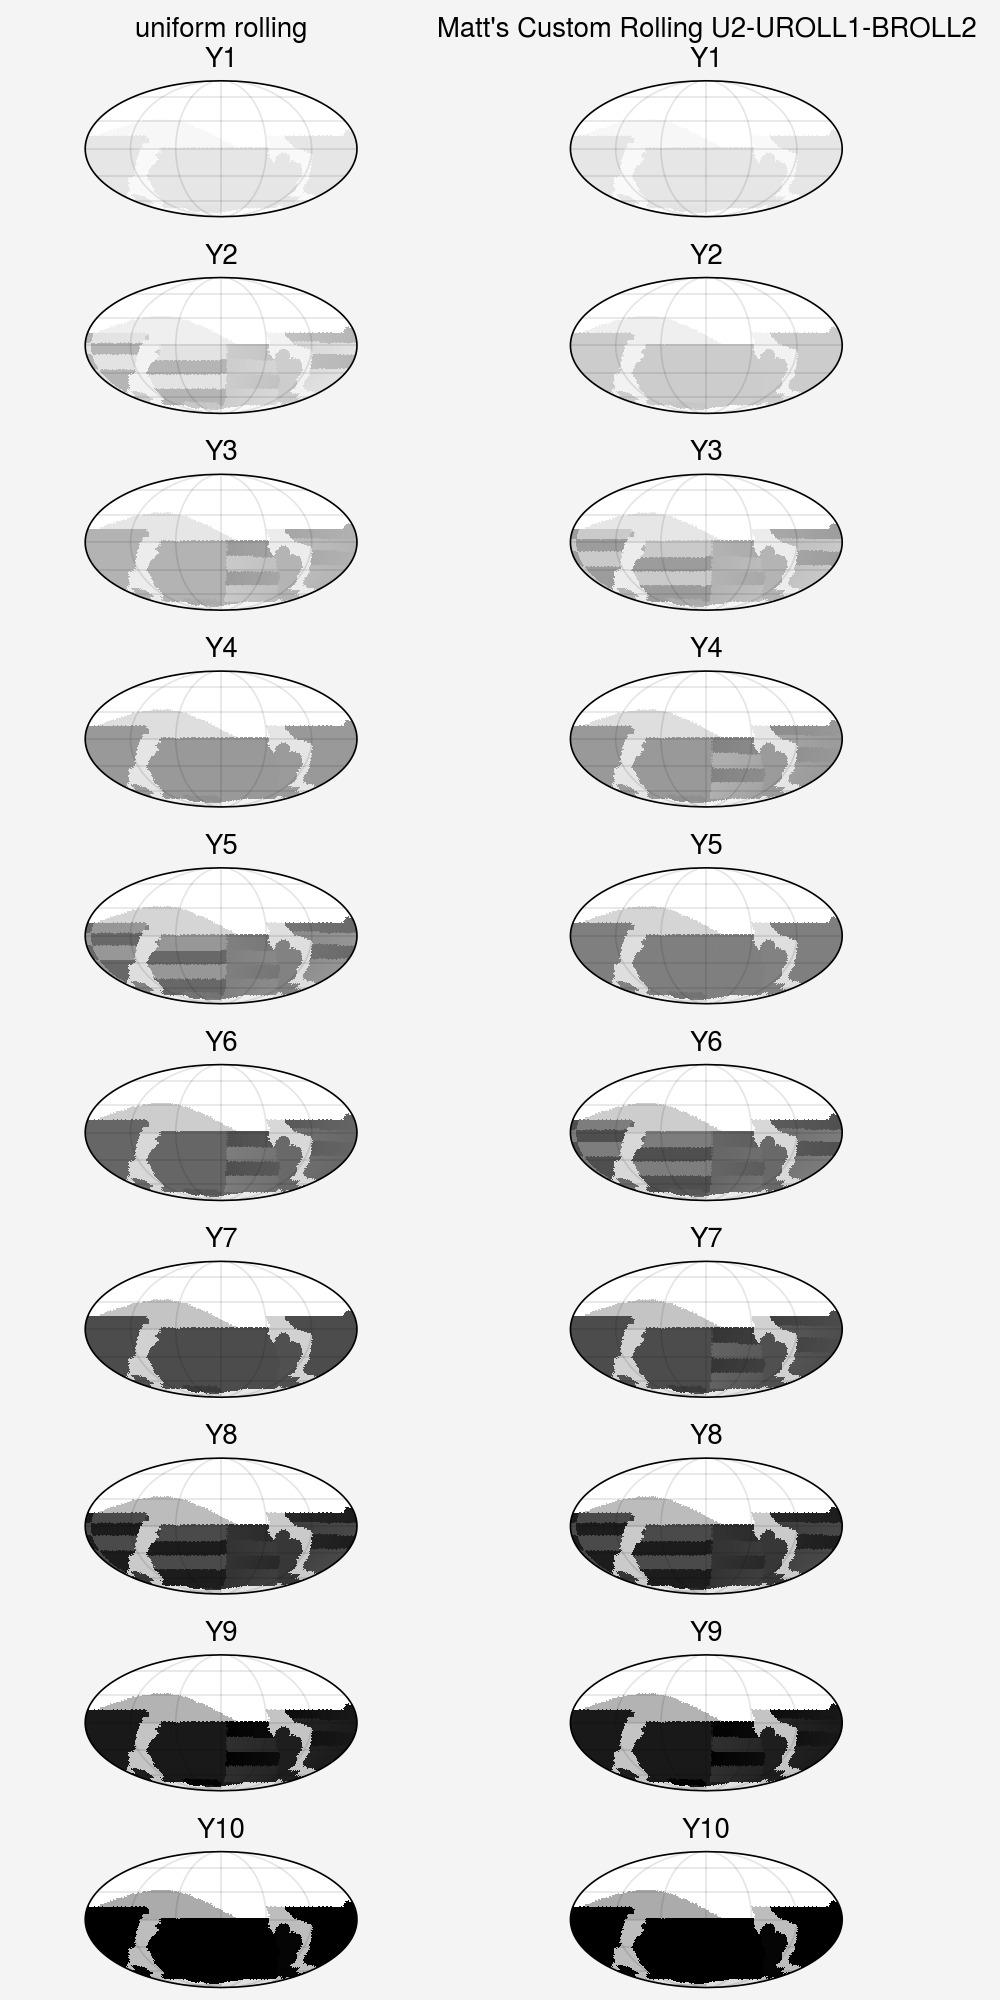

In [49]:
YEAR = 365.25

fig, axs = uplt.subplots(nrows=10, ncols=2, figsize=(5, 10), proj="moll")
for i in range(10):
    year = i + 1

    plot_map_at_mjd(axs[i, 0], footprints, survey_start_mjd + year * YEAR, cmap="gray_r")
    if i == 0:
        axs[i, 0].format(title=f"uniform rolling\nY{year}")
    else:
        axs[i, 0].format(title=f"Y{year}")

    plot_map_at_mjd(axs[i, 1], special_footprints, survey_start_mjd + year * YEAR, cmap="gray_r")
    if i == 0:
        axs[i, 1].format(title=f"Matt's Custom Rolling U2-UROLL1-BROLL2\nY{year}")
    else:
        axs[i, 1].format(title=f"Y{year}")